Точность для service_108: 0.9998398975
Точность для service_116: 1.0000000000


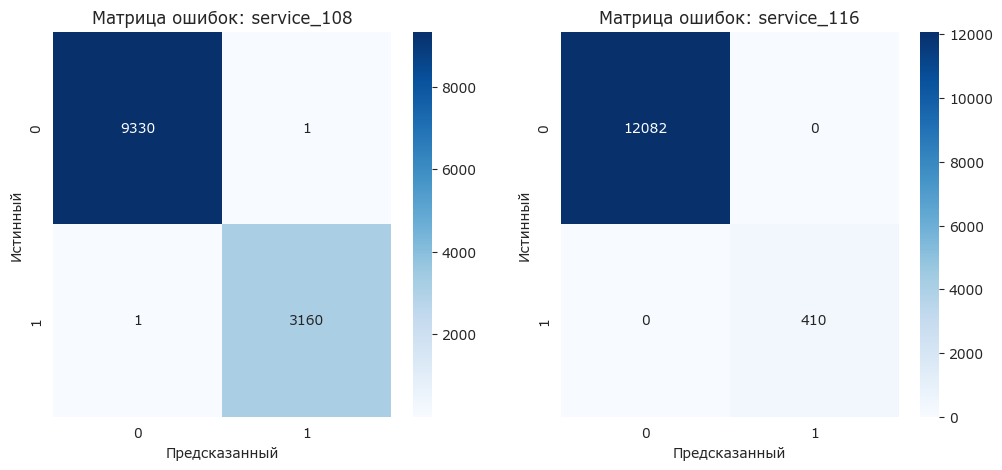

Ошибочные для 108


,age,child_number,family_size,income,study_certificate,isEgisso,true_target,pred_target,prob_target
13573,0,1,2,33751,0,0,1,0,0.017935
10444,9,1,3,50913,0,0,0,1,0.619170


Ошибочные для 116


,age,child_number,family_size,income,study_certificate,isEgisso,true_target,pred_target,prob_target


Модель сохранена в models\mlp_with_scaler.onnx


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

plt.rc('font', family='Verdana')

# Загружаем данные
file_path = '../resources/dataset_108_116.csv'
data = pd.read_csv(file_path).drop(columns=["living_minimum"]).drop_duplicates()

# Определяем признаки и целевые переменные (услуги)
features = ["age", "child_number", "family_size", "income", "study_certificate", "isEgisso"]
service_columns = ["service_108", "service_116"]

X = data[features]
y = data[service_columns]  # y — это сразу несколько услуг (многовыходная модель)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Масштабируем данные (нормализация 0-1)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучаем модель
mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[10])
mlp.fit(X_train_scaled, y_train)

# Прогнозируем
y_pred = mlp.predict(X_test_scaled)

# Получаем вероятности предсказания
y_prob = mlp.predict_proba(X_test_scaled)

# Оценка точности по каждой услуге
for i, service in enumerate(service_columns):
    acc = accuracy_score(y_test[service], y_pred[:, i])
    print(f"Точность для {service}: {acc:.10f}")

# Визуализируем матрицы ошибок
fig, axes = plt.subplots(1, len(service_columns), figsize=(6 * len(service_columns), 5))

for i, service in enumerate(service_columns):
    cm = confusion_matrix(y_test[service], y_pred[:, i])

    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[i])
    axes[i].set_title(f"Матрица ошибок: {service}")
    axes[i].set_xlabel("Предсказанный")
    axes[i].set_ylabel("Истинный")

plt.show()

# Ошибки для 108
print("Ошибочные для 108")
# Ошибочные индексы
wrong_idx_108 = (y_test["service_108"] != y_pred[:, 0])
errors_108 = X_test[wrong_idx_108].copy()
errors_108["true_target"] = y_test["service_108"][wrong_idx_108]
errors_108["pred_target"] = y_pred[:, 0][wrong_idx_108]
errors_108["prob_target"] = y_prob[:, 0][wrong_idx_108]
display(errors_108)

# Ошибки для 116
print("Ошибочные для 116")
# Ошибочные индексы
wrong_idx_116 = (y_test["service_116"] != y_pred[:, 1])
errors_116 = X_test[wrong_idx_116].copy()
errors_116["true_target"] = y_test["service_116"][wrong_idx_116]
errors_116["pred_target"] = y_pred[:, 1][wrong_idx_116]
errors_116["prob_target"] = y_prob[:, 1][wrong_idx_116]
display(errors_116)

# Создаём конвейер (Pipeline), объединяющий нормализатор и модель
pipeline = Pipeline([
    ("scaler", scaler),
    ("mlp", mlp)
])

# Определяем входную форму (число признаков)
input_shape = FloatTensorType([None, X_train.shape[1]])

# Конвертируем в ONNX
options = {"zipmap": False}
onnx_model = convert_sklearn(
    pipeline,
    initial_types=[("input", input_shape)],
    options={id(mlp): options}
)

# skl2onnx по умолчанию создает конкатенацию вероятностей положительного и отрицательного классов
# оставим в модели только вероятности положительного класса
# 1. Получаем структуру модели
graph = onnx_model.graph
# 2. Удаляем узлы `Concat` и `Sub`
nodes_to_remove = [node for node in graph.node if node.op_type in ["Concat", "Sub"]]
for node in nodes_to_remove:
    graph.node.remove(node)
# 3. Меняем выход модели: меняем probabilities на out_activations_result
for output in graph.output:
    if output.name == "probabilities":  # Было: %probabilities = Concat(...)
        output.name = "out_activations_result"  # Теперь возвращается только сигмоидный выход

# Сохраняем модель в файл
onnx_path = "models\\mlp_with_scaler.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Модель сохранена в {onnx_path}")

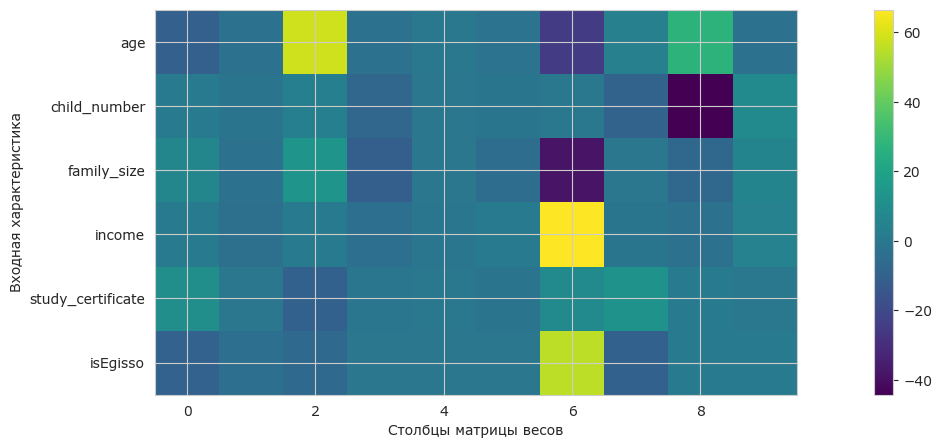

In [2]:
# веса, которые были вычислены при подключении входного слоя к первому скрытому слою.
# Строки в этом графике соответствуют 6 входным признакам, а столбцы – 10 скрытым элементам. 
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(6), features)
plt.xlabel("Столбцы матрицы весов")
plt.ylabel("Входная характеристика")
plt.colorbar()